In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

plt.rcParams.update({
    "font.size": 8,
    "axes.linewidth": 1.0,
    "font.family": "Arial"
})
sns.set(style="ticks", font="Arial")

# Load data
path_A = "/Users/suthardr/Desktop/astrocyte_NEWcxtA_Gaussian_noise3_all.csv"
path_B = "/Users/suthardr/Desktop/astrocyte_NEWcxtB_Gaussian_noise3_all.csv"
path_FC = "/Users/suthardr/Desktop/astrocyte_shot_Gaussian_noise3_all.csv"

df_A = pd.read_csv(path_A)
df_B = pd.read_csv(path_B)
df_FC = pd.read_csv(path_FC)

#create context column
df_A["context"] = "CxtA"
df_B["context"] = "CxtB"
df_FC["context"] = "FC"

# assign sex from animal string (F/M)
for d in (df_A, df_B, df_FC):
    d["sex"] = d["animal"].str.upper().str.contains("F").map({True: "F", False: "M"})

# set variance = NaN when 0 or non-numeric
for d in (df_A, df_B, df_FC):
    d["variance"] = pd.to_numeric(d["variance"], errors="coerce")
    d.loc[d["variance"] == 0, "variance"] = np.nan

# combined cell-level dataframe
df_all = pd.concat([df_A, df_B, df_FC], ignore_index=True)
df_all = df_all.dropna(subset=["variance", "animal", "context", "sex"])

print("Cell counts per context, sex:")
print(df_all.groupby(["context", "sex"])["variance"].count())

Cell counts per context, sex:
context  sex
CxtA     F       535
         M       819
CxtB     F       227
         M       596
FC       F      1376
         M      1672
Name: variance, dtype: int64


Cell counts per context, sex:
context  sex
CxtA     F       535
         M       819
CxtB     F       227
         M       596
FC       F      1376
         M      1672
Name: variance, dtype: int64


/var/folders/5r/7j2h9rcx719_l9q157yrh3nw0000gq/T/ipykernel_80415/1175468991.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


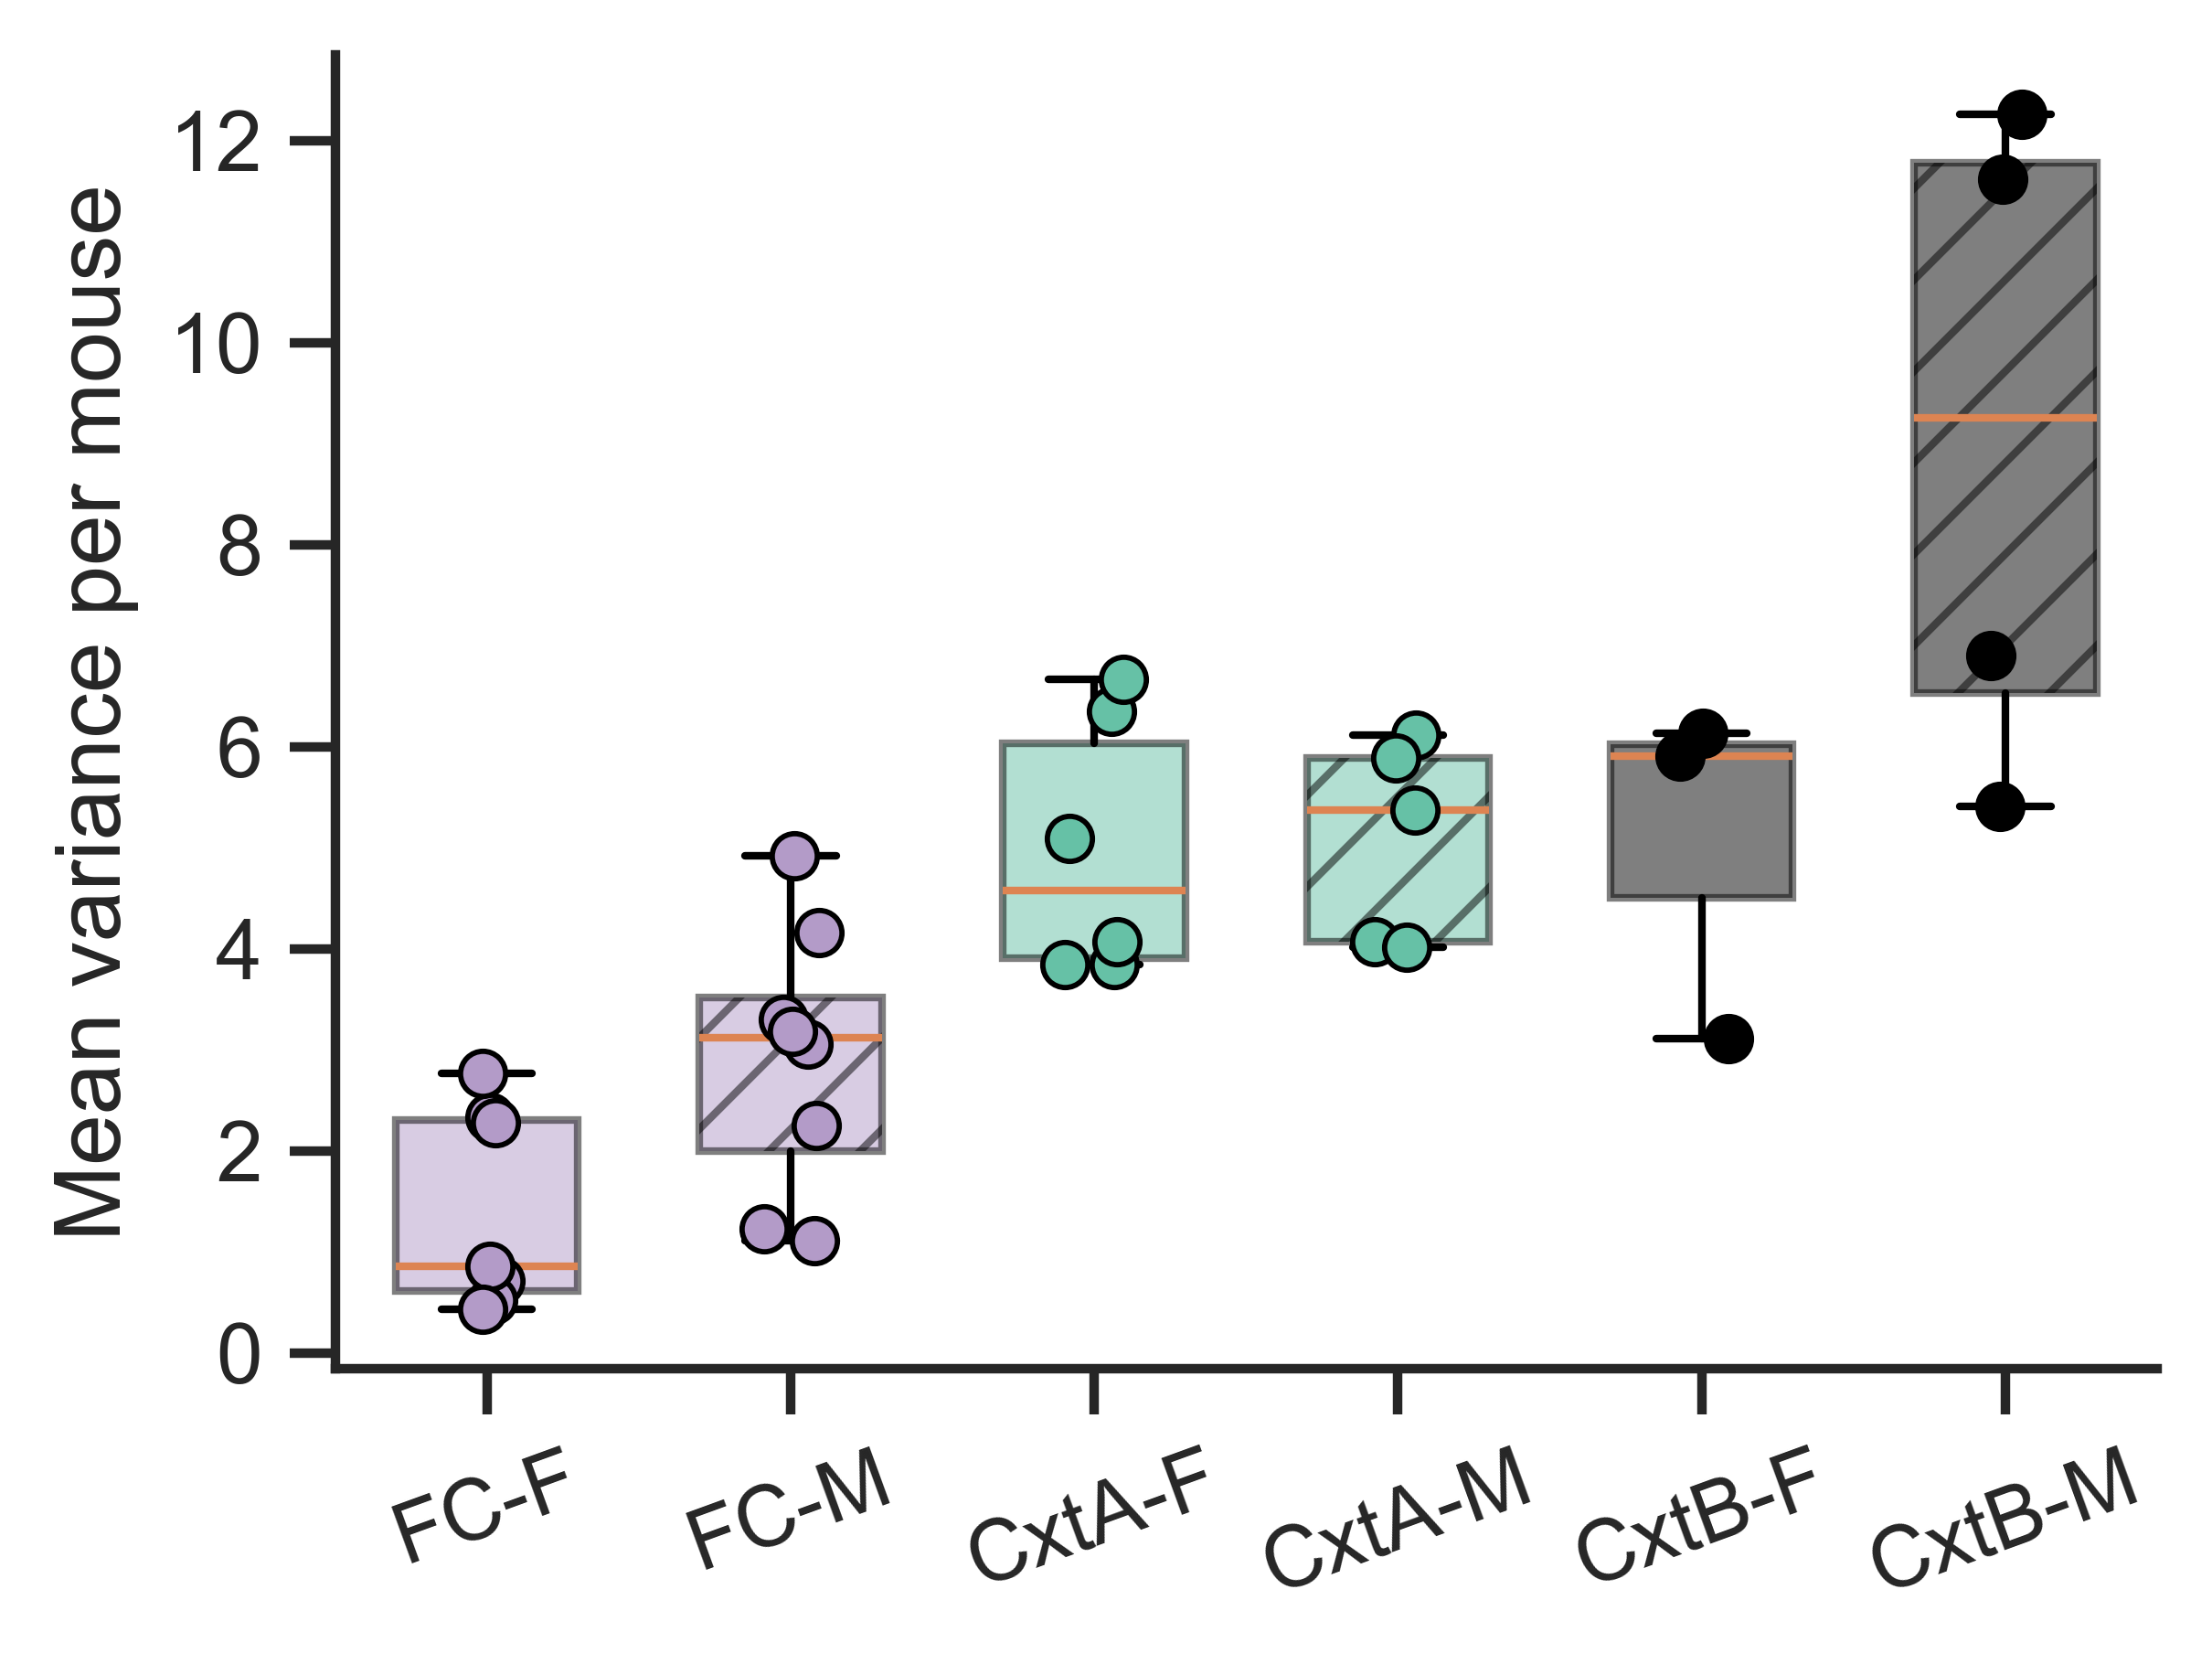

In [4]:

# Mouse-level 6-group plot (FC-F, FC-M, CxtA-F, CxtA-M, CxtB-F, CxtB-M)
mouse_avg = (
    df_all.groupby(["animal", "sex", "context"])["variance"]
    .mean()
    .dropna()
    .reset_index()
)

FC_F = mouse_avg[(mouse_avg["context"] == "FC") & (mouse_avg["sex"] == "F")]["variance"]
FC_M = mouse_avg[(mouse_avg["context"] == "FC") & (mouse_avg["sex"] == "M")]["variance"]
A_F = mouse_avg[(mouse_avg["context"] == "CxtA") & (mouse_avg["sex"] == "F")]["variance"]
A_M = mouse_avg[(mouse_avg["context"] == "CxtA") & (mouse_avg["sex"] == "M")]["variance"]
B_F = mouse_avg[(mouse_avg["context"] == "CxtB") & (mouse_avg["sex"] == "F")]["variance"]
B_M = mouse_avg[(mouse_avg["context"] == "CxtB") & (mouse_avg["sex"] == "M")]["variance"]

groups_mouse = [FC_F, FC_M, A_F, A_M, B_F, B_M]
labels_mouse = ["FC-F", "FC-M", "CxtA-F", "CxtA-M", "CxtB-F", "CxtB-M"]

fc_color = "#B39BC8"
cxtA_color = "#66C1A6"
cxtB_color = "black"

colors_mouse = [fc_color, fc_color, cxtA_color, cxtA_color, cxtB_color, cxtB_color]
hatches = ["", "//", "", "//", "", "//"]
positions = np.arange(1, 7)

fig, ax = plt.subplots(figsize=(4.5, 3.5), dpi=600)

bp = ax.boxplot(
    groups_mouse,
    positions=positions,
    widths=0.6,
    labels=labels_mouse,
    patch_artist=True
)

for patch, color, hatch in zip(bp["boxes"], colors_mouse, hatches):
    patch.set_facecolor(color)
    patch.set_edgecolor("black")
    patch.set_alpha(0.5)
    patch.set_hatch(hatch)

np.random.seed(0)
jitter = 0.10

for x_pos, vals, color in zip(positions, groups_mouse, colors_mouse):
    vals = np.array(vals)
    if len(vals) == 0:
        continue
    x = x_pos + np.random.uniform(-jitter, jitter, size=len(vals))
    ax.scatter(
        x, vals,
        s=35,
        color=color,
        edgecolor="black",
        linewidth=0.7,
        zorder=3
    )

ax.set_ylabel("Mean variance per mouse")
ax.tick_params(axis="x", rotation=20)
sns.despine(ax=ax)
plt.tight_layout(pad=2)
plt.show()

/var/folders/5r/7j2h9rcx719_l9q157yrh3nw0000gq/T/ipykernel_80415/611604096.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bp = sns.boxplot(
/var/folders/5r/7j2h9rcx719_l9q157yrh3nw0000gq/T/ipykernel_80415/611604096.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/var/folders/5r/7j2h9rcx719_l9q157yrh3nw0000gq/T/ipykernel_80415/611604096.py:88: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sex_xlabels, rotation=0)


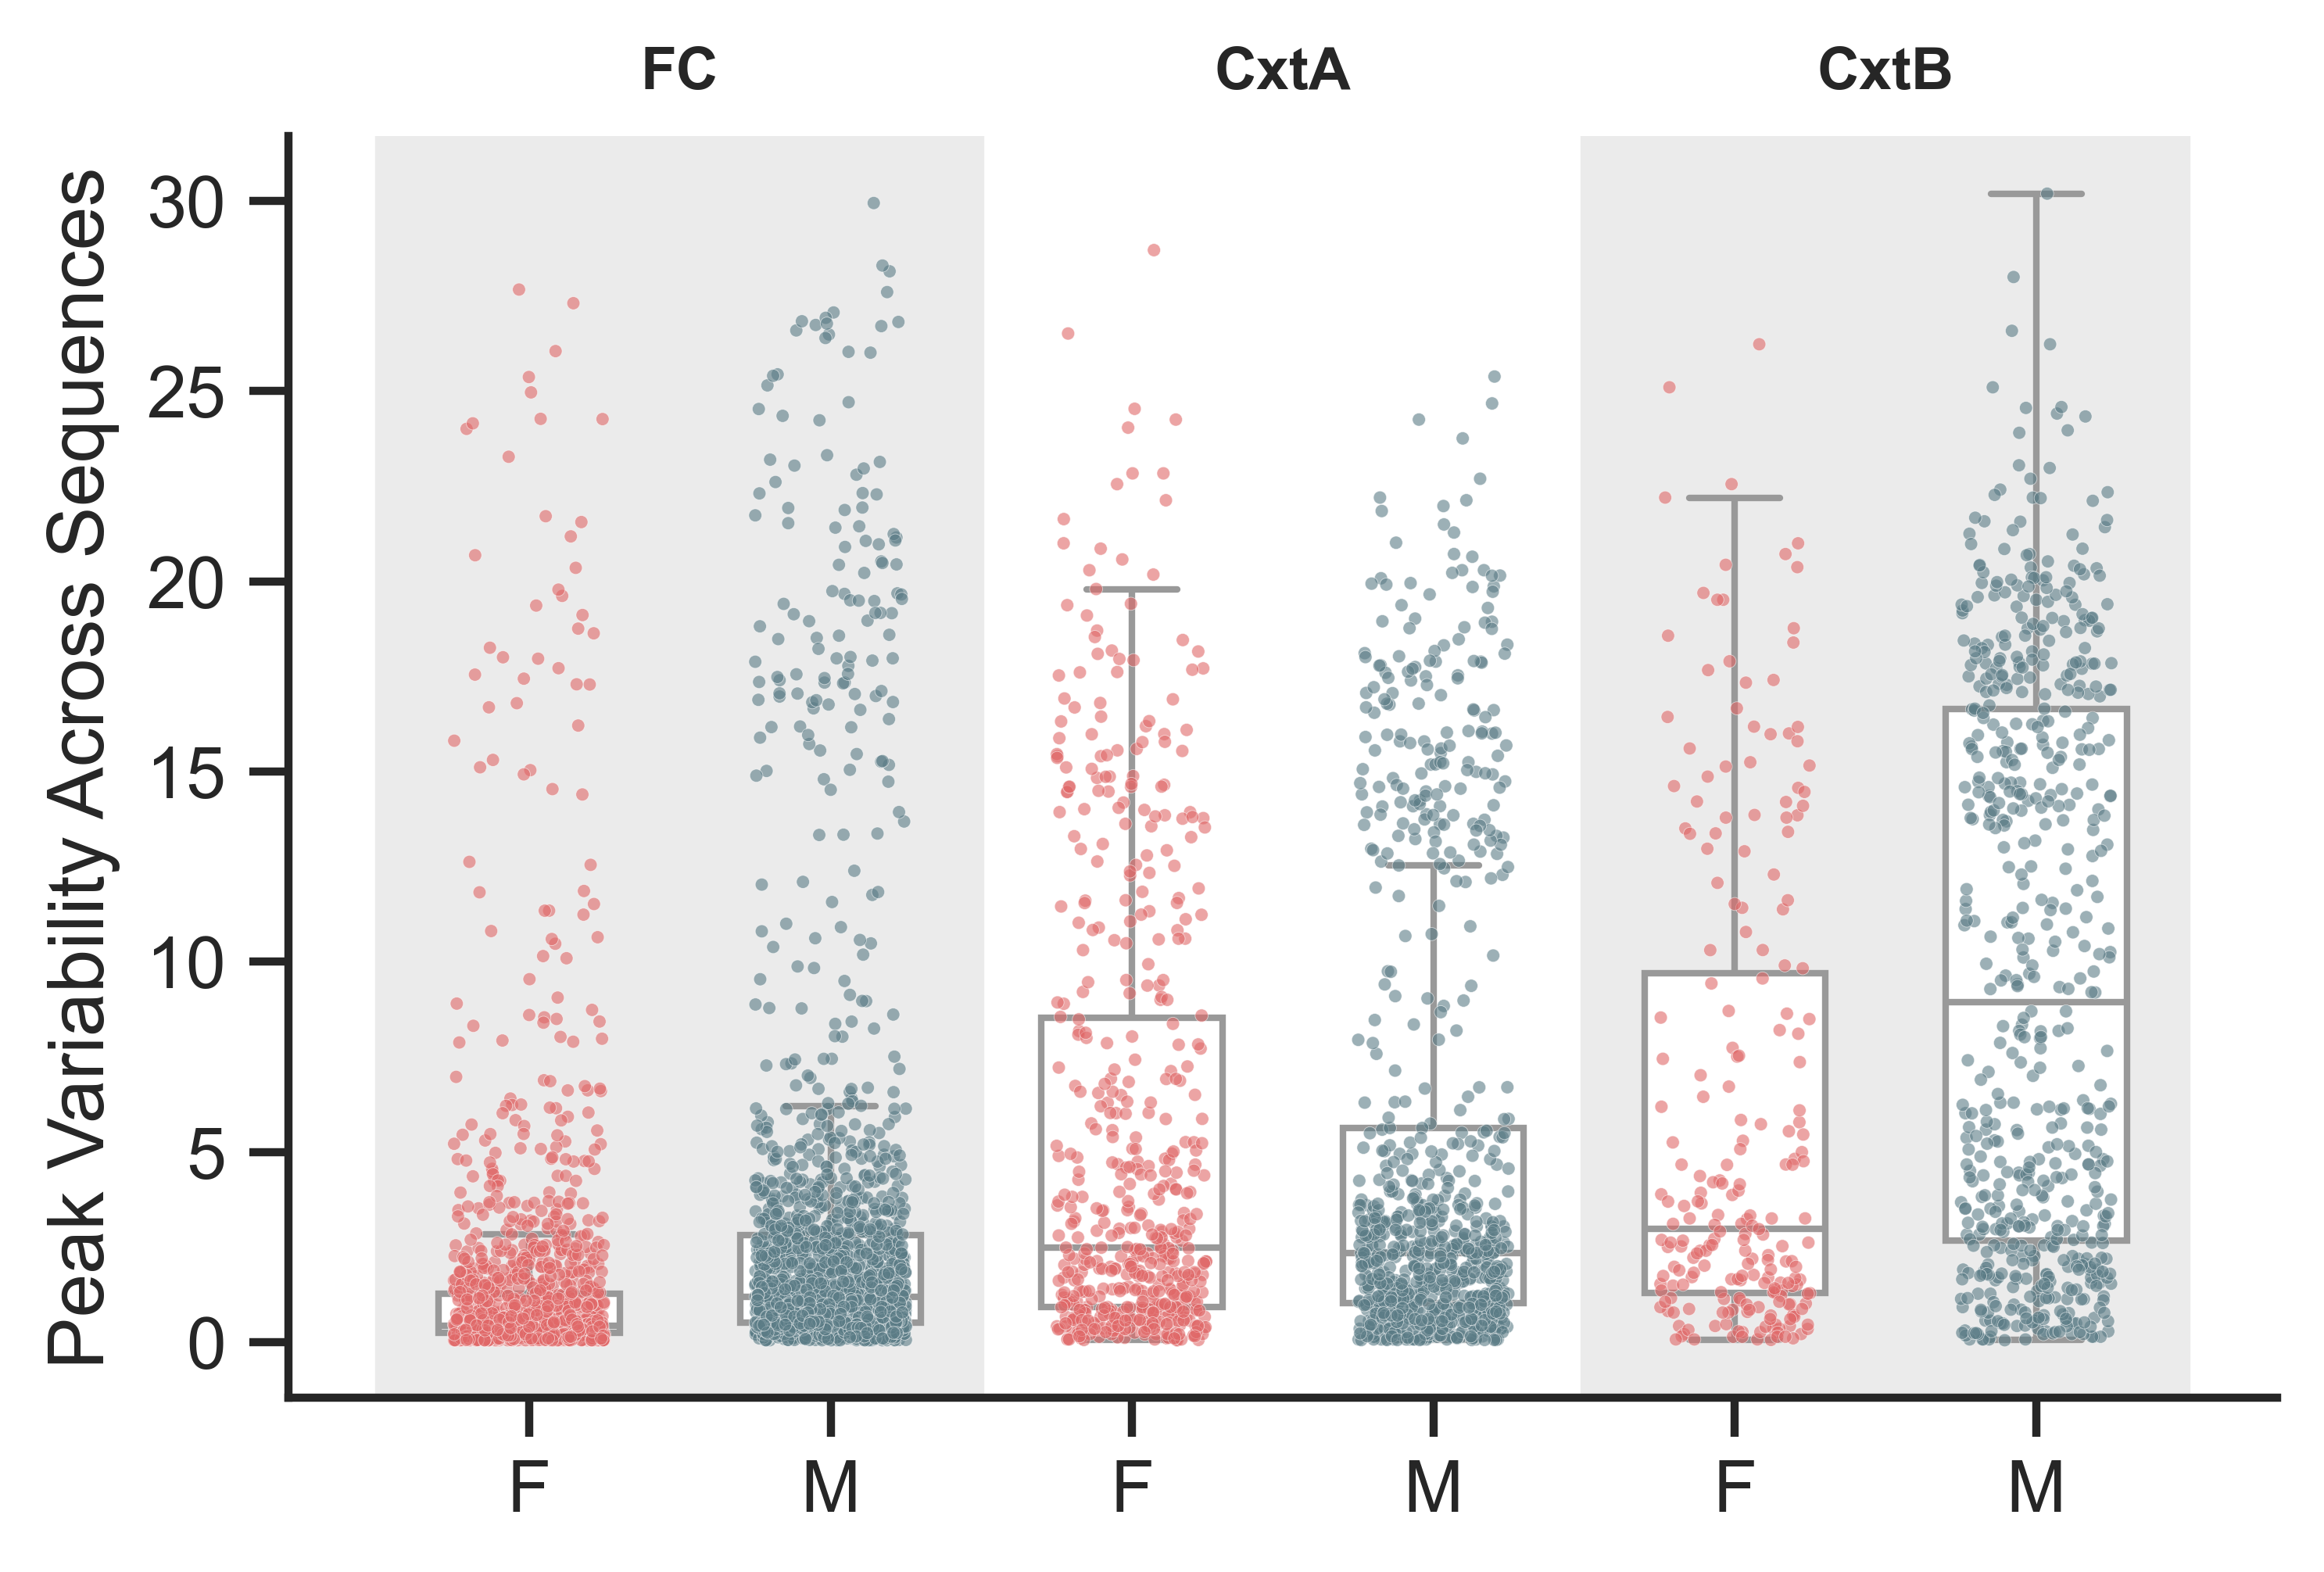

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

sns.set(style="ticks", font="Arial")
plt.rcParams.update({'font.size': 8})

# Sex colors
sex_palette = {
    "F": "#e06868",   # Female
    "M": "#5b7c86"    # Male
}

# Group order
order_6 = ["FC-F", "FC-M", "CxtA-F", "CxtA-M", "CxtB-F", "CxtB-M"]

# Ensure group column exists
df_all["group"] = df_all["context"] + "-" + df_all["sex"]
df_all["group"] = pd.Categorical(df_all["group"], categories=order_6, ordered=True)

# Colors based on sex
palette_6 = [sex_palette[g.split("-")[1]] for g in order_6]

fig, ax = plt.subplots(figsize=(5.2, 3.6), dpi=600)

# Boxplot (white fill, colored outlines by sex)
bp = sns.boxplot(
    data=df_all,
    x="group",
    y="variance",
    order=order_6,
    ax=ax,
    palette=["white"] * 6,
    width=0.6,
    showfliers=False
)

for patch, color in zip(bp.artists, palette_6):
    patch.set_facecolor("white")
    patch.set_edgecolor(color)
    patch.set_linewidth(1.3)

# Stripplot of individual cells
sns.stripplot(
    data=df_all,
    x="group",
    y="variance",
    order=order_6,
    ax=ax,
    palette=palette_6,
    jitter=0.25,
    size=2,
    alpha=0.6,
    edgecolor="white",
    linewidth=0.1
)

# Add context grouping background shading
group_boundaries = {
    "FC":   (0 - 0.5, 1 + 0.5),   # covers FC-F, FC-M
    "CxtA": (2 - 0.5, 3 + 0.5),   # covers CxtA-F, CxtA-M
    "CxtB": (4 - 0.5, 5 + 0.5),   # covers CxtB-F, CxtB-M
}

shade_color = (0.92, 0.92, 0.92)
for i, (ctx, (start, end)) in enumerate(group_boundaries.items()):
    if i % 2 == 0:
        ax.axvspan(start, end, color=shade_color, zorder=0)

# Context labels above (FC, CxtA, CxtB)
y_top = ax.get_ylim()[1]
for ctx in ["FC", "CxtA", "CxtB"]:
    start, end = group_boundaries[ctx]
    midpoint = (start + end) / 2
    ax.text(
        midpoint,
        y_top * 1.03,
        ctx,
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

# Label x-axis as sex per bar
sex_xlabels = ["F", "M", "F", "M", "F", "M"]
ax.set_xticklabels(sex_xlabels, rotation=0)

# Remove legend if seaborn created one
if ax.get_legend():
    ax.get_legend().remove()

# Formatting
ax.set_xlabel("")
ax.set_ylabel("Peak Variability Across Sequences")
sns.despine()
plt.tight_layout(pad=2)
plt.rcParams['svg.fonttype'] = 'none'

plt.savefig(
    '/Volumes/rkc_ramirezlab/Home/rsenne/dCA1_Clean_Data/revision_analysis/'
    'Figure3_Recall/peak_var_Fig3/individual_cells_FC_A_B_bySex_peak_var.svg',
    dpi=600,
    bbox_inches='tight'
)

plt.show()


In [89]:
# LMM for 6 groups (sex × context)
import statsmodels.formula.api as smf

# Make sure context and sex are categorical
df_all["context"] = df_all["context"].astype("category")
df_all["sex"] = df_all["sex"].astype("category")

# Fit LMM: variance ~ sex * context + (1 | animal)
model_6 = smf.mixedlm(
    "variance ~ C(sex) * C(context)",
    df_all,
    groups=df_all["animal"]
)

res_6 = model_6.fit(method="lbfgs")
print(res_6.summary())


                  Mixed Linear Model Regression Results
Model:                    MixedLM       Dependent Variable:       variance
No. Observations:         5225          Method:                   REML    
No. Groups:               15            Scale:                    28.4079 
Min. group size:          172           Log-Likelihood:           inf     
Max. group size:          688           Converged:                Yes     
Mean group size:          348.3                                           
--------------------------------------------------------------------------
                               Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------
Intercept                      -1.818                                     
C(sex)[T.M]                    -1.376                                     
C(context)[T.CxtB]              0.092    0.432   0.214 0.831 -0.754  0.938
C(context)[T.FC]               -3.660    0.2

/Users/suthardr/opt/anaconda3/envs/dca1_rescue/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/suthardr/opt/anaconda3/envs/dca1_rescue/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/Users/suthardr/opt/anaconda3/envs/dca1_rescue/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/suthardr/opt/anaconda3/envs/dca1_rescue/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/Users/suthardr/opt/anaconda3/envs/dca1_rescue/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_mo

Cell counts per context:
context
FC      3048
CxtA    1354
CxtB     823
Name: variance, dtype: int64 



/var/folders/5r/7j2h9rcx719_l9q157yrh3nw0000gq/T/ipykernel_18297/2801559712.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_3.groupby("context")["variance"].count(), "\n")
/var/folders/5r/7j2h9rcx719_l9q157yrh3nw0000gq/T/ipykernel_18297/2801559712.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bp = sns.boxplot(
/var/folders/5r/7j2h9rcx719_l9q157yrh3nw0000gq/T/ipykernel_18297/2801559712.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


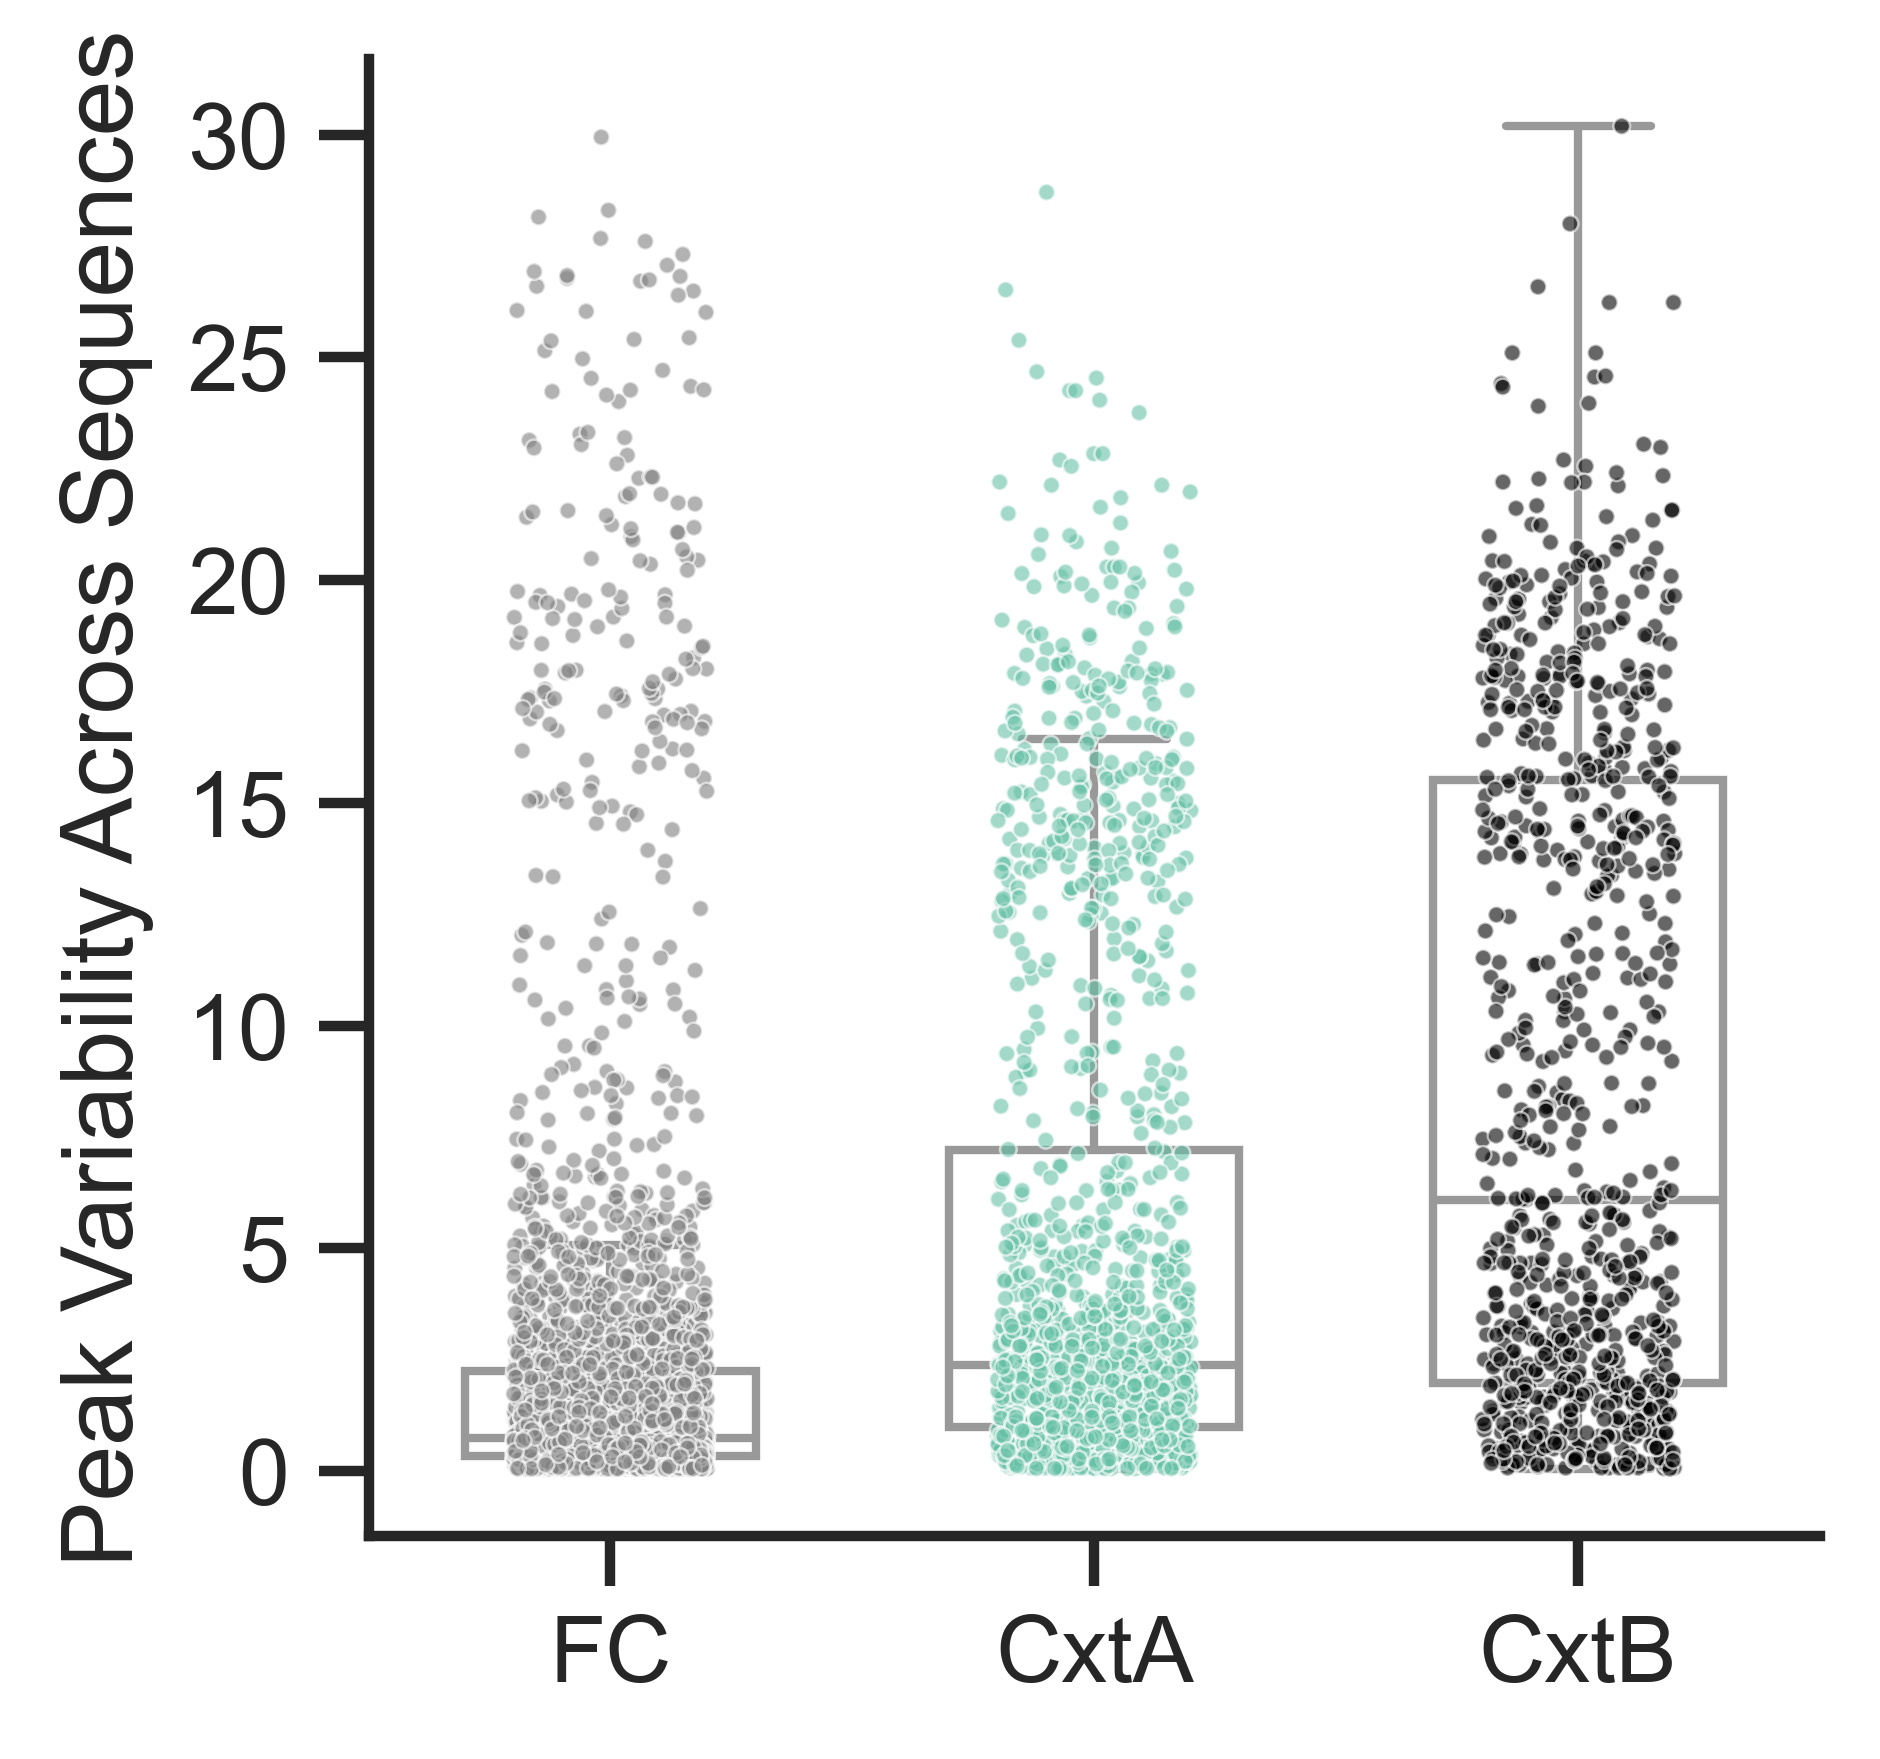

In [81]:
# Cell-level 3-group plot (FC, CxtA, CxtB) and LMM

df_3 = df_all.copy()
df_3["context"] = df_3["context"].astype("category")
df_3["context"] = df_3["context"].cat.reorder_categories(["FC", "CxtA", "CxtB"], ordered=True)

print("Cell counts per context:")
print(df_3.groupby("context")["variance"].count(), "\n")

order_3 = ["FC", "CxtA", "CxtB"]
palette_3 = [context_colors[c] for c in order_3]

fig, ax = plt.subplots(figsize=(3.6, 3.4), dpi=600)

bp = sns.boxplot(
    data=df_3,
    x="context",
    y="variance",
    order=order_3,
    ax=ax,
    palette=["white"] * 3,
    width=0.6,
    showfliers=False
)

for patch, color in zip(bp.artists, palette_3):
    patch.set_facecolor("white")
    patch.set_edgecolor(color)
    patch.set_linewidth(1.3)

sns.stripplot(
    data=df_3,
    x="context",
    y="variance",
    order=order_3,
    ax=ax,
    palette=palette_3,
    dodge=False,
    jitter=0.2,
    size=2,
    alpha=0.6,
    edgecolor="white",
    linewidth=0.3
)

ax.set_xlabel("")
ax.set_ylabel("Peak Variability Across Sequences")
sns.despine(ax=ax)
plt.tight_layout(pad=2)
plt.rcParams['svg.fonttype'] = 'none'

plt.savefig(
    '/Volumes/rkc_ramirezlab/Home/rsenne/dCA1_Clean_Data/revision_analysis/Figure3_Recall/peak_var_Fig3/individual_cells_FC_A_B_peak_var.svg',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

In [77]:
model = smf.mixedlm(
    "variance ~ C(context)",
    df_3,
    groups=df_3["animal"]
)
res = model.fit(method="lbfgs")
print(res.summary())


            Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   variance
No. Observations:    5225      Method:               REML    
No. Groups:          15        Scale:                28.6954 
Min. group size:     172       Log-Likelihood:       inf     
Max. group size:     688       Converged:            Yes     
Mean group size:     348.3                                   
-------------------------------------------------------------
                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept          -4.134                                    
C(context)[T.CxtA]  3.002    0.191 15.746 0.000  2.629  3.376
C(context)[T.CxtB]  5.521    0.236 23.401 0.000  5.059  5.983
Group Var           0.000                                    



/Users/suthardr/opt/anaconda3/envs/dca1_rescue/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/suthardr/opt/anaconda3/envs/dca1_rescue/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/Users/suthardr/opt/anaconda3/envs/dca1_rescue/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/suthardr/opt/anaconda3/envs/dca1_rescue/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/Users/suthardr/opt/anaconda3/envs/dca1_rescue/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_mo

In [84]:
import statsmodels.stats.multicomp as multi

# predicted means for each context
means = df_3.groupby("context")["variance"].mean()
groups = ["FC", "CxtA", "CxtB"]

posthoc = multi.pairwise_tukeyhsd(
    endog=df_3["variance"],
    groups=df_3["context"],
    alpha=0.05
)

print(posthoc)


/var/folders/5r/7j2h9rcx719_l9q157yrh3nw0000gq/T/ipykernel_18297/1861197889.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = df_3.groupby("context")["variance"].mean()


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
  CxtA   CxtB   3.4642   0.0  2.8927  4.0356   True
  CxtA     FC  -2.8202   0.0 -3.2425  -2.398   True
  CxtB     FC  -6.2844   0.0 -6.7923 -5.7765   True
---------------------------------------------------
